The simulation procedure for generating dependent, heavy-tailed functional densities is conducted in four primary stages, moving from the $L^2[0,1]$ Hilbert space back to the space of probability density functions.

The transformed functional process $\psi_t(u)$ is modeled as a combination of a static heavy-tailed template and a stochastic functional perturbation:
\begin{equation}
    \psi_t(u) = \psi_{\text{ref}}(u) + \sum_{k=1}^K \xi_{k,t} \phi_k(u)
\end{equation}
where:

* $\psi_{\text{ref}}(u) = \ln(Q'_{\text{ref}}(u))$ is the mLQDT of a Student-$t$ distribution with $\nu$ degrees of freedom.
* $\phi_k(u) = \sqrt{2} \cos(k \pi u)$ represents the orthonormal cosine basis functions.
* $\xi_{k,t}$ are temporal scores following independent AR(1) processes:
    \begin{equation}
        \xi_{k,t} = \varphi_k \xi_{k,t-1} + \varepsilon_{k,t}, \quad \varepsilon_{k,t} \sim N(0, \sigma_k^2)
    \end{equation}

To reconstruct the physical distribution, we first derive the Quantile Function $Q_t(u)$ by exponentiating the mLQDT curve and integrating over the domain $[0,1]$:
\begin{equation}
    Q_t(u) = \int_0^u \exp(\psi_t(s)) \, ds
\end{equation}

To ensure the resulting densities are centered at zero (consistent with financial return data), we calculate the time-varying mean $\mu_t$ and define the centered quantile function $Q_{t, \text{center}}(u)$:
\begin{align}
    \mu_t &= \int_0^1 Q_t(u) \, du \\
    Q_{t, \text{center}}(u) &= Q_t(u) - \mu_t
\end{align}

Finally, the observed density $f_t(x)$ is obtained through the inverse relationship of the quantile derivative:
\begin{equation}
    f_t(x) = \frac{1}{Q'_t(Q_{t, \text{center}}^{-1}(x))}
\end{equation}
where $Q_{t, \text{center}}^{-1}(x)$ denotes the cumulative distribution function (CDF) at time $t$.

In [23]:
import numpy as np 
import pandas as pd
from scipy.stats import norm, t
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt
import plotly.express as px

import sys
sys.path.append("..")
from src.preprocessing import align_densities
from src.kde import verify_density_area 
from src.transformations import (
                            dens2lqd,
                            lqd2dens,
                            mLQDT,
                            obtain_lqds,
                            obtain_densities_from_lqd,
                            modes_of_variation,
                            compute_lqd_cut
                            )
from src.simulations import normal_density, t_density, gaussian_mixture_density, t_mixture_density, simulate_dependent_densities, sample_from_density
from src.plotting import px_select_menu

Data Generating Process

Let $\{f_t : t = 1, \dots, T\}$ denote a sequence of probability density functions defined on a common support $\mathcal{X} \subset \mathbb{R}$.

We consider a baseline density $f_0$ belonging to a parametric family, such as the Gaussian distribution, Student-$t$ distribution, or a finite mixture of Gaussian distributions.

Let $\{X_t(u) : u \in [0,1]\}$ denote the functional representation of $f_t$ in a suitable function space. The dynamics are introduced through a finite-dimensional representation:
\begin{equation}
X_t(u) = X_0(u) + \sum_{k=1}^{K} \beta_{t,k} \, \phi_k(u),
\end{equation}
where $\{\phi_k\}_{k=1}^K$ is a set of orthonormal basis functions and $\{\beta_{t,k}\}$ are time-varying coefficients.

The coefficients follow independent autoregressive processes:
\begin{equation}
\beta_{t,k} = \phi_k \, \beta_{t-1,k} + \varepsilon_{t,k}, \quad t = 2, \dots, T,
\end{equation}
where $\phi_k \in (-1,1)$ and $\varepsilon_{t,k} \sim \mathcal{N}(0, \sigma^2)$ are independent innovations.

The sequence of densities $\{f_t\}$ is obtained by mapping $\{X_t\}$ back to the space of valid probability densities.

## Monte Carlo Experiment

The finite-sample performance of the proposed forecasting method is assessed via a Monte Carlo experiment.

For each replication $r = 1, \dots, R$, the following steps are performed:


A baseline density $f_0^{(r)}$ is generated from one of the following scenarios:
    
    * (A) Gaussian distribution,
    * (B) Student-$t$ distribution with moderate degrees of freedom,
    * (C) Student-$t$ distribution with low degrees of freedom,
    * (D) Gaussian mixture distribution.
    
A sequence of functional observations $\{X_t^{(r)}\}_{t=1}^T$ is generated according to the dynamic model:
\begin{equation}
X_t^{(r)}(u) = X_0^{(r)}(u) + \sum_{k=1}^{K} \beta_{t,k}^{(r)} \, \phi_k(u).
\end{equation}

The corresponding sequence of densities $\{f_t^{(r)}\}_{t=1}^T$ is obtained.
    
A forecasting model is estimated using observations up to time $t$, and one-step-ahead forecasts $\hat{f}_{t+1}^{(r)}$ are produced in a rolling scheme.
    
Forecast accuracy is evaluated by comparing $\hat{f}_{t+1}^{(r)}$ with $f_{t+1}^{(r)}$ using suitable loss functions.

The above procedure is repeated independently for $R$ replications, and the results are averaged across replications.

1. Skew-Student-t (Azzalini Type)
\begin{equation}
f(x; \xi, \omega, \alpha, \nu) = \frac{2}{\omega} t_{\nu} \left( \frac{x - \xi}{\omega} \right) T_{\nu + 1} \left( \alpha \left( \frac{x - \xi}{\omega} \right) \sqrt{\frac{\nu + 1}{\nu + (\frac{x - \xi}{\omega})^2}} \right)
\end{equation}

2. Normal Inverse Gaussian (NIG)
\begin{equation}
f(x; \alpha, \beta, \delta, \mu) = \frac{\alpha \delta K_1 \left( \alpha \sqrt{\delta^2 + (x - \mu)^2} \right)}{\pi \sqrt{\delta^2 + (x - \mu)^2}} \exp(\delta \sqrt{\alpha^2 - \beta^2} + \beta(x - \mu))
\end{equation}

<!-- 3. Levy Stable Distribution (Characteristic Function)
\begin{equation}
\ln \phi(t) = it\mu - |ct|^\alpha \left( 1 - i\beta \text{sgn}(t) \Phi \right)
\text{where } \Phi = \tan\left(\frac{\pi\alpha}{2}\right) \text{ if } \alpha \neq 1, \text{ and } \Phi = -\frac{2}{\pi} \ln|t| \text{ if } \alpha = 1
\end{equation} -->

4. Jump-Diffusion (Merton Model)
\begin{equation}
f(x) = \sum_{n=0}^{\infty} \frac{e^{-\lambda} \lambda^n}{n!} \cdot \frac{1}{\sqrt{2\pi \sigma_n^2}} \exp \left( -\frac{(x - \mu_n)^2}{2\sigma_n^2} \right)
\end{equation}

<!-- 5. Generalized Pareto Distribution (GPD)
\begin{equation}
f(x; \sigma, \xi) = \frac{1}{\sigma} \left( 1 + \frac{\xi x}{\sigma} \right)^{-\left( \frac{1}{\xi} + 1 \right)}
\end{equation} -->

6. Spliced Normal-GPD Mixture
\begin{cases} 
\frac{1-2\phi}{\beta} \left( 1 + \frac{\xi(-x-u)}{\beta} \right)^{-\left( \frac{1}{\xi} + 1 \right)} & \text{if } x < -u \\ 
\frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right) & \text{if } -u \le x \le u \\ 
\frac{1-2\phi}{\beta} \left( 1 + \frac{\xi(x-u)}{\beta} \right)^{-\left( \frac{1}{\xi} + 1 \right)} & \text{if } x > u 
\end{cases}

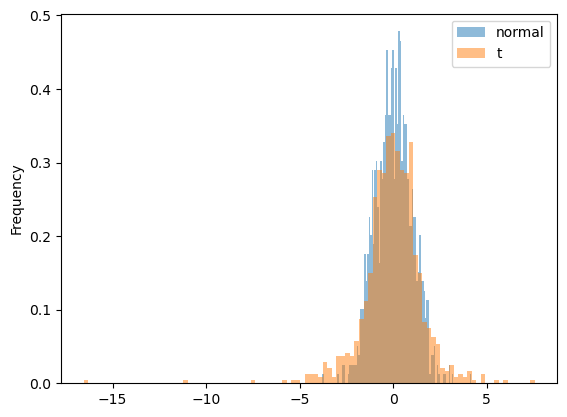

In [4]:
# Parameters
n = 1000  # sample size
df = 3    # degrees of freedom (lower = heavier tails)

# Simulation
samples_t = pd.Series(np.random.standard_t(df=df, size=n))
samples_t2 = pd.Series(np.random.standard_t(df=5, size=n))
samples_n = pd.Series(np.random.normal(loc=0, scale=1, size=n))

# samples_t2.plot(kind="hist", bins=100, density=True, label="t2", alpha=.5)
samples_n.plot(kind="hist", bins=100, density=True, label="normal", alpha=.5)
samples_t.plot(kind="hist", bins=100, density=True, label="t", alpha=.5)
plt.legend()
plt.show()

In [5]:
# 1. Define a dense grid for the x-axis
# Using 1000 points makes the curve look perfectly smooth
x = np.linspace(-6, 6, 1000)

# 2. Calculate the "True" PDF values (not random samples)
pdf_t3     = t_density(x, df=3)
pdf_t5     = t_density(x, df=5)
pdf_normal = normal_density(x)

pdf_mixture = gaussian_mixture_density(
    x,
    weights=[0.9, 0.1],
    locs=[0, 0],
    scales=[1, 5]
)

pdf_mixture_t = t_mixture_density(
        x,
    weights=[0.8, 0.2],
    dfs=[10, 3],
    locs=[0, 0],
    scales=[1, 2]
)

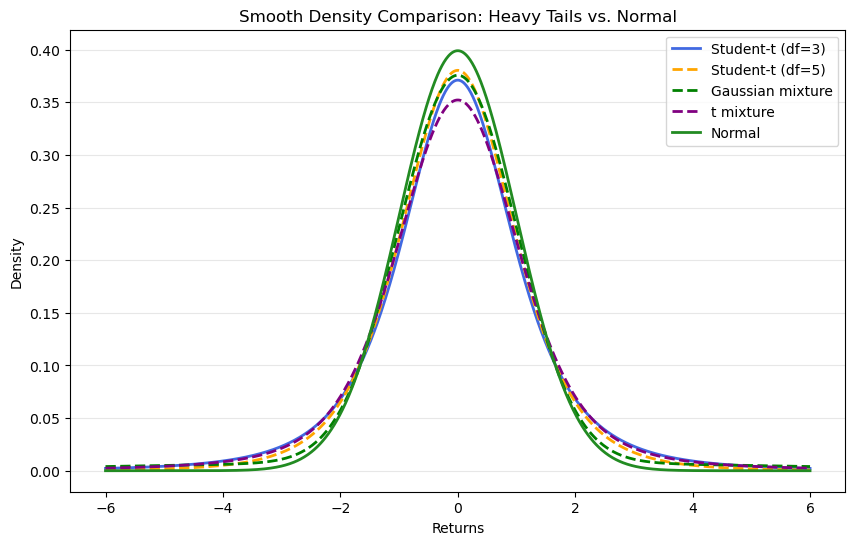

In [6]:
# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_t3, label="Student-t (df=3)", color="royalblue", lw=2)
plt.plot(x, pdf_t5, label="Student-t (df=5)", color="orange", lw=2, linestyle="--")
plt.plot(x, pdf_mixture, label="Gaussian mixture", color="green", lw=2, linestyle="--")
plt.plot(x, pdf_mixture_t, label="t mixture", color="purple", lw=2, linestyle="--")
plt.plot(x, pdf_normal, label="Normal", color="forestgreen", lw=2)

# plt.fill_between(x, pdf_t3, alpha=0.1, color="royalblue")
plt.title("Smooth Density Comparison: Heavy Tails vs. Normal")
plt.xlabel("Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [72]:
lqd_support = np.linspace(0,1,5001)
lqdsup, lqd_t, c = dens2lqd(
                        dens = pdf_t3, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = 0,
                        verbose=True
                        )
lqdsup, lqd_n, c = dens2lqd(
                        dens = pdf_normal, 
                        dSup = x, 
                        lqdSup=lqd_support, 
                        t0 = 0,
                        verbose=True
                        )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.
t0 is not a value in dSup - resetting to closest value
t0 is not a value in dSup - resetting to closest value


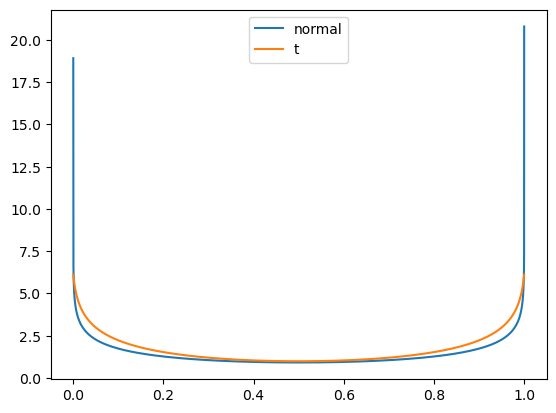

In [73]:
plt.figure()

plt.plot(lqdsup, lqd_n, label="normal")
plt.plot(lqdsup, lqd_t, label="t")

plt.legend()
plt.show()

<Axes: >

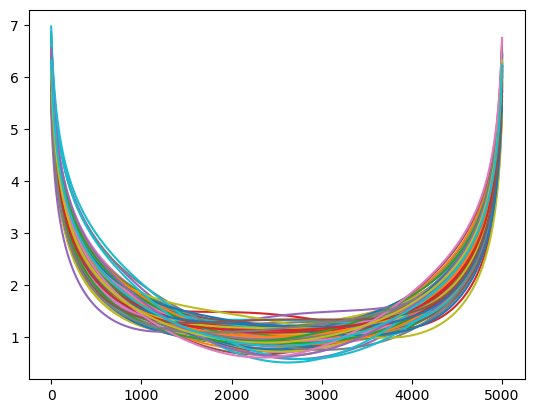

In [29]:
# lqd_t = lqd
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = simulate_dependent_densities(100, lqd_t, phis)
df_lqds_t = pd.DataFrame(curves)
df_lqds_t.plot(legend=False)

<Axes: >

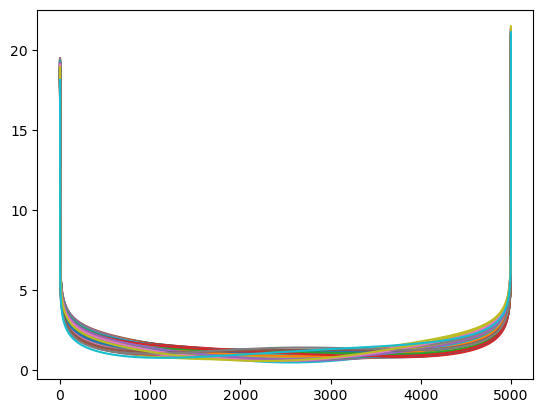

In [30]:
phis = [0.8, -0.5] # Strong persistence in shape 1, oscillating shape 2
curves, _ = simulate_dependent_densities(100, lqd_n, phis)
df_lqds_n = pd.DataFrame(curves)
df_lqds_n.plot(legend=False)

In [ ]:
bkw_supports_t, bkw_densities_t = obtain_densities_from_lqd(
                                                            df_lqds_t,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )

bkw_supports_n, bkw_densities_n = obtain_densities_from_lqd(
                                                            df_lqds_n,
                                                            lqd_support,
                                                            c_=[c for i in range(df_lqds_t.shape[1])],
                                                            t_=[0 for i in range(df_lqds_t.shape[1])],
                                                            verbose=False
                                                            )

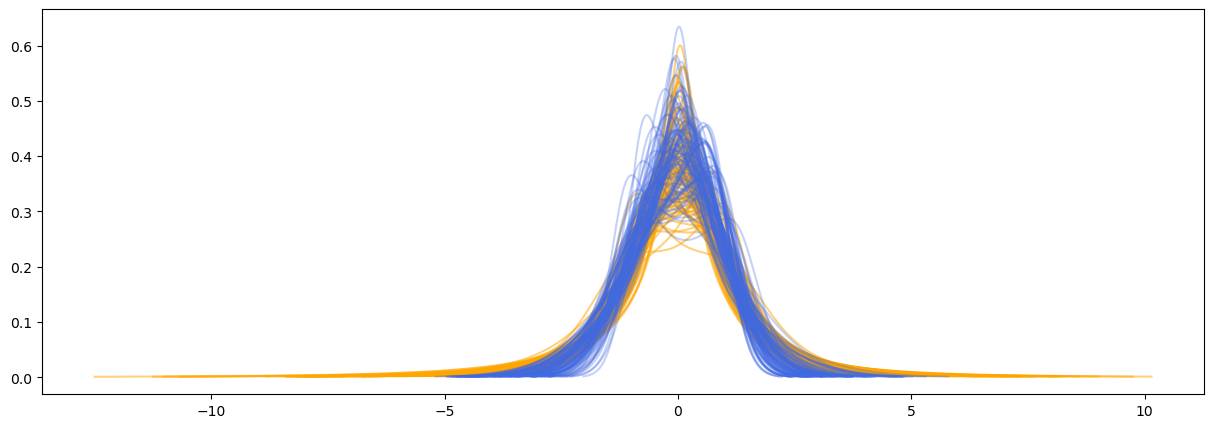

In [49]:
plt.figure(figsize=(15,5))
for i in range(bkw_densities_t.shape[1]):
    plt.plot(bkw_supports_t.iloc[:,i], bkw_densities_t.iloc[:,i], c="orange", label= "t-student", alpha=.5)

for i in range(bkw_densities_n.shape[1]):
    plt.plot(bkw_supports_n.iloc[:,i], bkw_densities_n.iloc[:,i], c="royalblue", label="normal", alpha=.3)
plt.show()

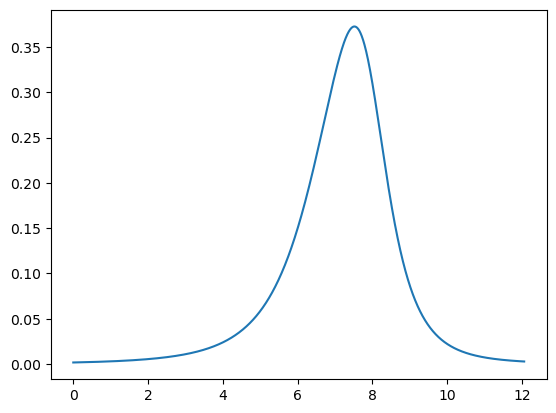

In [26]:
t = -1

plt.figure()

plt.plot(kle_bkw_supports.iloc[:, t], kle_bkw_densities.iloc[:, t])

plt.show()

In [27]:
# Usage with your data:
returns_day_1 = sample_from_density(kle_bkw_supports.iloc[:, t], kle_bkw_densities.iloc[:, t])

<Axes: ylabel='Frequency'>

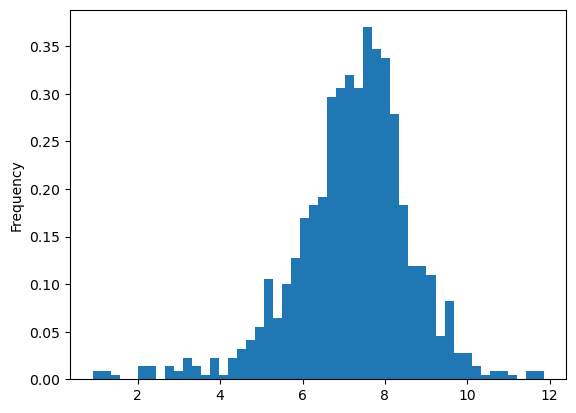

In [28]:
pd.Series(returns_day_1).plot(kind="hist", bins=50,density=True)

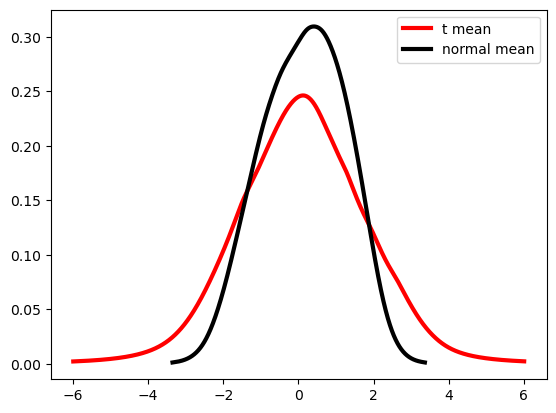

In [53]:
plt.plot(
    bkw_supports_t.iloc[:,0],
    bkw_densities_t.mean(axis=1),
    c="red",
    lw=3,
    label="t mean"
)

plt.plot(
    bkw_supports_n.iloc[:,0],
    bkw_densities_n.mean(axis=1),
    c="black",
    lw=3,
    label="normal mean"
)

plt.legend()

plt.show()

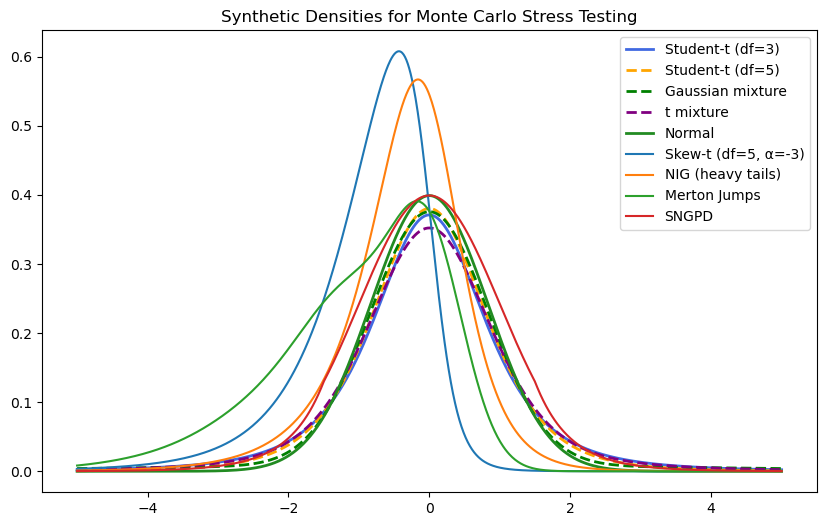

In [26]:
from scipy.stats import norm, t, norminvgauss, levy_stable, genpareto
import math


# --- Simulation Parameters ---
x = np.linspace(-5, 5, 1000)

# Generate PDFs
pdf_skewt = skew_t_pdf(x, df=5, alpha=-3)  # Negative skew for market crashes
pdf_nig   = norminvgauss.pdf(x, a=1.5, b=-0.5) # Heavy tails + asymmetry
# pdf_stable = levy_stable.pdf(x, alpha=1.7, beta=-0.2) # Infinite variance potential
pdf_merton = merton_jump_pdf(x, mu=0, sigma=0.5, lamb=1.0, muj=-1.0, sigmaj=0.5)
pdf_gpd    = genpareto.pdf(x, c=0.2, loc=0, scale=1) # Tail behavior focus
## Spliced normal GPD (SNGPD)
# Case A: Light tails (xi small)
y_light = spliced_normal_gpd(x, u=1.5, xi=0.05)
# Case B: Heavy tails (xi large, typical for Bitcoin/High Volatility)
y_heavy = spliced_normal_gpd(x, u=1.5, xi=0.4)

# --- Visualization for Verification ---
plt.figure(figsize=(10, 6))

plt.plot(x, pdf_t3, label="Student-t (df=3)", color="royalblue", lw=2)
plt.plot(x, pdf_t5, label="Student-t (df=5)", color="orange", lw=2, linestyle="--")
plt.plot(x, pdf_mixture, label="Gaussian mixture", color="green", lw=2, linestyle="--")
plt.plot(x, pdf_mixture_t, label="t mixture", color="purple", lw=2, linestyle="--")
plt.plot(x, pdf_normal, label="Normal", color="forestgreen", lw=2)
plt.plot(x, pdf_skewt, label='Skew-t (df=5, α=-3)')
plt.plot(x, pdf_nig, label='NIG (heavy tails)')
# plt.plot(x, pdf_stable, label='Levy Stable (α=1.7)')
plt.plot(x, pdf_merton, label='Merton Jumps', linestyle='-')
# plt.plot(x, pdf_gpd, label='GPD', linestyle='--')
plt.plot(x, y_light, label='SNGPD')
# plt.plot(x, y_heavy, label='SNGPD heavy', linestyle='--')

plt.title("Synthetic Densities for Monte Carlo Stress Testing")
plt.legend()
plt.show()

In [27]:
# 1. Consolidate your existing arrays into a DataFrame
# (Assuming x, pdf_t3, pdf_t5, etc., are already defined in your environment)
df = pd.DataFrame({
    "x": x,
    "Student-t (df=3)": pdf_t3,
    "Student-t (df=5)": pdf_t5,
    "Gaussian mixture": pdf_mixture,
    "t mixture": pdf_mixture_t,
    "Normal": pdf_normal,
    "Skew-t (df=5, α=-3)": pdf_skewt,
    "NIG (heavy tails)": pdf_nig,
    # "Levy Stable (α=1.7)": pdf_stable,
    "Merton Jumps": pdf_merton,
    # "GPD": pdf_gpd,
    "SNGPD": y_light
})

# 2. Generate the simplified plot
fig = px.line(
    df, 
    x="x", 
    y=[col for col in df.columns if col != "x"],
    title="Synthetic Densities: Comparative Overview",
    labels={"value": "Density", "variable": "Distribution", "x": "Returns"},
    template="plotly_white"
)

# 3. Apply uniform styling to all traces
fig.update_traces(line=dict(width=2))

# 4. Final layout cleanup
fig.update_layout(
    legend_title_text='Model Type',
    # hovermode="x unified",
    xaxis=dict(range=[-8, 8]), # Focusing on the relevant distribution area
    yaxis=dict(title="Probability Density")
)

px_select_menu(fig)
fig.show()